## Imports

In [ ]:
y_kmeans = [0, 0, 0, 1, 1, 1, 2, 2]

y_true = [1, 1, 1, 2, 2, 2, 3, 3]

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import cv2
from sklearn.metrics import pairwise_distances

# import o pacote para calcular a silhueta e o NMI
from sklearn.metrics import silhouette_score, normalized_mutual_info_score

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import SpectralClustering
from matplotlib import rcParams
rcParams['figure.figsize'] = 15, 15

## Construindo o Dataset

In [ ]:
dataset_path = './images/*.png'
images_filenames = glob.glob(dataset_path)

images_filenames = np.sort(images_filenames)

img_arry = []
for img_path in images_filenames:
  img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2GRAY)
  img_arry.append(img.flatten())

image_dataset = pd.DataFrame(img_arry)

print('shape:', image_dataset.shape)
image_dataset.head()

shape: (174, 16384)


,0,1,2,3,4,5,6,7,8,9,...,16374,16375,16376,16377,16378,16379,16380,16381,16382,16383
0,49,47,25,25,25,25,25,25,25,25,...,25,25,25,25,25,25,25,25,25,25
1,49,47,27,27,27,27,27,27,27,27,...,27,27,27,27,27,27,27,27,27,27
2,49,47,27,27,27,27,27,27,27,27,...,27,27,27,27,27,27,27,27,27,27
3,49,47,27,27,27,27,27,27,27,27,...,27,27,27,27,27,27,27,27,27,27
4,49,47,26,26,26,26,26,26,26,26,...,26,26,26,26,26,26,26,26,26,26


## Visualizando o Resultado Inicial da Clusterização

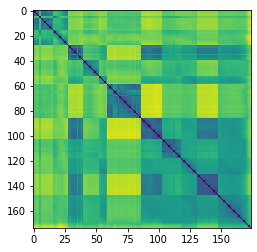

In [ ]:
p = pairwise_distances(image_dataset, metric='euclidean')
plt.imshow(p, interpolation='nearest')

In [ ]:
# plote o valor da inércia e silhueta para o número de clusters variando de 2 à 15
inertias = []
silhouettes = []

for i in range(2,16):
  model = KMeans(n_clusters=i).fit(image_dataset)

  inertias.append(model.inertia_)
  
  labels = model.labels_
  silhouette = silhouette_score(image_dataset, labels, metric='euclidean')
  silhouettes.append(silhouette)

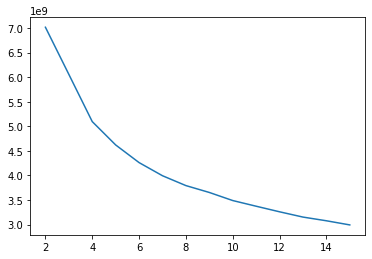

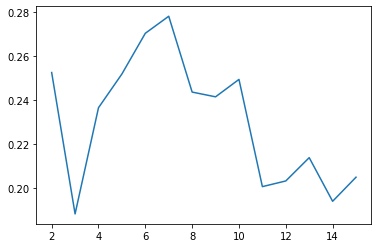

In [ ]:
#inertia
plt.plot(inertias)
plt.show()

#silhueta
plt.plot(silhouettes)
plt.show()


# Testando Alguns Algoritmos de Clustering

In [ ]:
def plot_images_by_cluster(images_filenames, y, cluster_idx):
  print(f'cluster {cluster_idx}')

  fig, ax = plt.subplots(1, len(images_filenames[y==cluster_idx]))
  i = 0
  for path in images_filenames[y==cluster_idx]:
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2GRAY)
    ax[i].imshow(img, cmap="gray")
    i = i + 1
  plt.show()

### K-Means

(7, 16384)
cluster 0


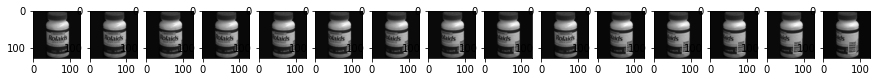

cluster 1


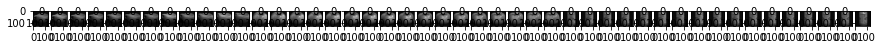

cluster 2


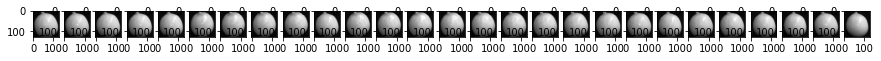

cluster 3


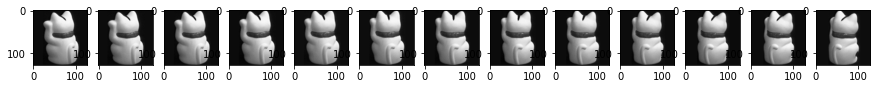

cluster 4


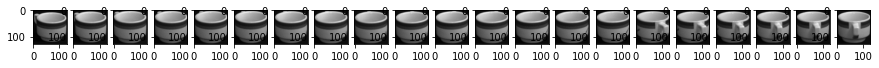

cluster 5


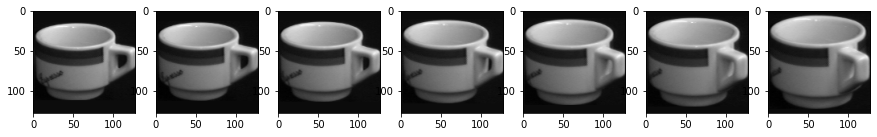

cluster 6


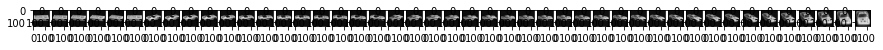

In [ ]:
# treine o k-means com n_clusters=k
kmeans = KMeans(n_clusters=7).fit(image_dataset)

y_kmeans = kmeans.labels_

print(kmeans.cluster_centers_.shape)

for k in range(max(y_kmeans) + 1):
  plot_images_by_cluster(images_filenames, y_kmeans, k)

### Aglomerativo

cluster 0


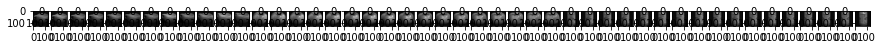

cluster 1


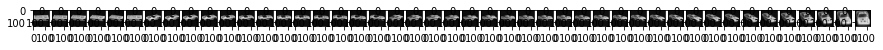

cluster 2


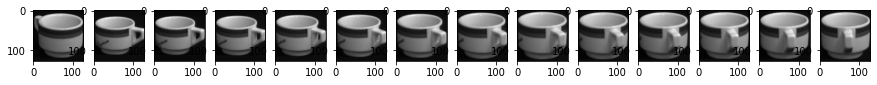

cluster 3


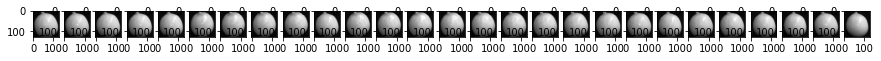

cluster 4


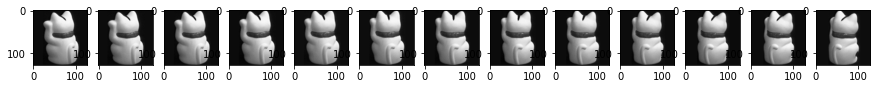

cluster 5


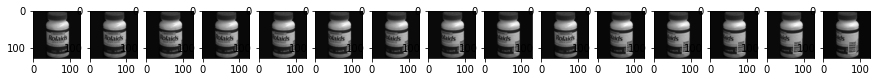

cluster 6


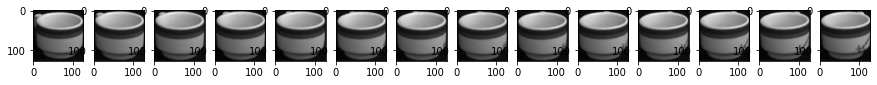

In [ ]:
# treine o cluster aglomerativo com n_clusters=k
agglomerative = AgglomerativeClustering(n_clusters=7).fit(image_dataset)

y_agglomerative = agglomerative.labels_

for k in range(max(y_agglomerative) + 1):
  plot_images_by_cluster(images_filenames, y_agglomerative, k)

### Spectral

/usr/local/lib/python3.8/dist-packages/sklearn/manifold/_spectral_embedding.py:260: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


cluster 0


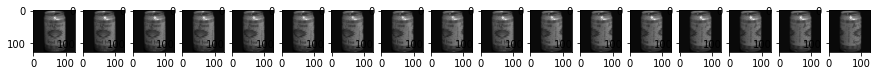

cluster 1


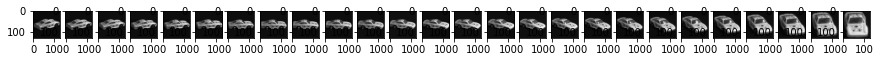

cluster 2


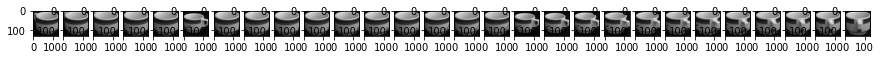

cluster 3


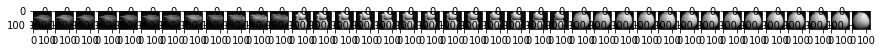

cluster 4


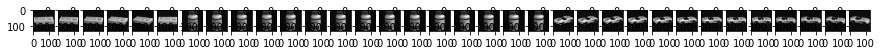

cluster 5


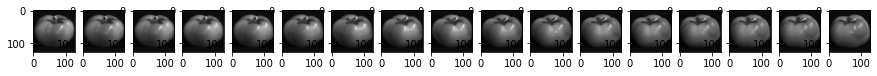

cluster 6


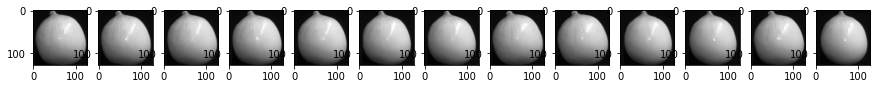

In [ ]:
# treine o Spectral clustering com o n_clusters=k

P = pairwise_distances(image_dataset, metric='euclidean')

spectral = SpectralClustering(n_clusters=7, affinity='precomputed_nearest_neighbors', n_neighbors=5, random_state=0).fit(P)

y_spectral = spectral.labels_

for k in range(max(y_spectral) + 1):
  plot_images_by_cluster(images_filenames, y_spectral, k)

## Análise dos Clusters

In [ ]:
# calcule a silhueta para os modelos
sil_kmeans = silhouette_score(image_dataset, kmeans.labels_, metric='euclidean')
sil_agglomerative = silhouette_score(image_dataset, agglomerative.labels_, metric='euclidean')
sil_spectral = silhouette_score(image_dataset, spectral.labels_, metric='euclidean')

print('Silhueta kmeans', sil_kmeans)
print('Silhueta agglomerative', sil_agglomerative)
print('Silhueta spectral', sil_spectral)

print('\n')

y_true = [path.split('/')[2].split('__')[0] for path in images_filenames]

# calcule o NMI para os modelos
nmi_kmeans = normalized_mutual_info_score(y_true, kmeans.labels_)
nmi_agglomerative = normalized_mutual_info_score(y_true, agglomerative.labels_)
nmi_spectral = normalized_mutual_info_score(y_true, spectral.labels_)

print('NMI Kmeans: ', nmi_kmeans)
print('NMI Aglomerativo: ', nmi_agglomerative)
print('NMI Spectral: ', nmi_spectral)

Silhueta kmeans 0.2780275507393124
Silhueta agglomerative 0.2641763365697744
Silhueta spectral 0.10938701004355947


NMI Kmeans:  0.8445755157834408
NMI Aglomerativo:  0.8401555303060414
NMI Spectral:  0.8645812868338988


In [ ]:
# reajuste os parâmetros e comente os resultados obtidos